Visualize the statistics.

In [ ]:
%cd -q ..
from impl.utils.visualization import Visualizer

Visualizer.visualize_in_one("out/solutions/statistics-1715715500855.pickle", show=True)
%cd -q test

Run the best complete solutions.

In [ ]:
%cd -q ..
from impl.scenario.simulation_runner import run_solutions

run_solutions("out/solutions/solutions-1715028728116.pickle", top=1)
%cd -q test

Visualize the violation.

          source     follow-up  ego-nearest-distance  \
0   8.039958e-06  8.039958e-06             17.045266   
1   3.578791e-08  3.578791e-08             17.113384   
2   4.294668e+00  4.294671e+00             13.677288   
3   1.122205e+00  5.811300e-01              5.664593   
4   1.122205e+00  3.054126e-01             12.152598   
5   1.985936e+00  3.300928e+00             13.123557   
6   2.237843e+00  3.300928e+00             13.123557   
7   1.119382e+00  9.346728e-04             13.854091   
8   1.119382e+00  2.432998e+00             14.308138   
9   3.869631e+00  4.152896e+00             16.571261   
10  5.113575e+00  5.414266e+00             20.858585   
11  5.113575e+00  5.115205e+00             25.812411   
12  4.901885e+00  4.673607e+00             30.774159   
13  4.901885e+00  4.715361e+00             34.340691   
14  4.428383e+00  4.216618e+00             38.722580   
15  4.846960e+00  5.176267e+00             42.858194   
16  4.687694e+00  4.661317e+00             47.09

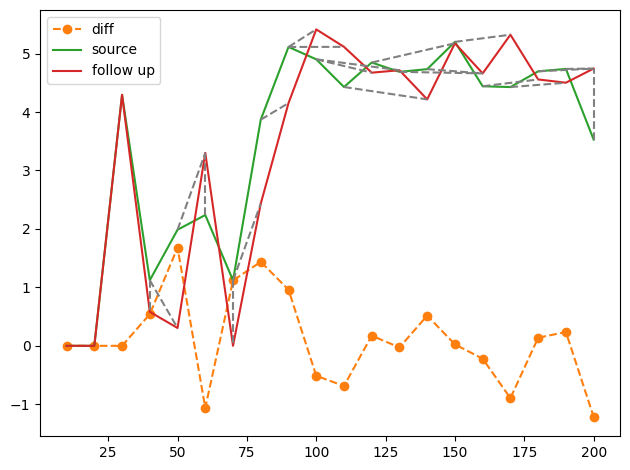

In [1]:
%cd -q ..
import math
import matplotlib.pyplot as plt
import pandas as pd
from tslearn.metrics import dtw_path
from impl.problem import mr_set

source = pd.read_csv("out/results/top1_source.csv")
source.set_index(source.columns[0], inplace=True)
follow_up = pd.read_csv("out/results/top1_follow-up.csv")
follow_up.set_index(follow_up.columns[0], inplace=True)

field = mr_set.field
if field == "velocity":
    func = lambda row: math.sqrt(row.velocity_x ** 2 + row.velocity_y ** 2)
    source[field] = source.apply(func, axis=1, result_type="reduce")
    follow_up[field] = follow_up.apply(func, axis=1, result_type="reduce")
print("is_violated: {}, extent: {}".format(*mr_set.is_violated(source, follow_up)))
%cd -q test

offset = 0
matches, _ = dtw_path(source[field], follow_up[field])
source["diff"] = source[field] - follow_up[field]
source[field] -= offset
fig, axs = plt.subplots()
axs.plot(list(source.index.values), list(source["diff"]), "o--C1", label="diff")
axs.plot(list(source.index.values), list(source[field]), "-C2", label="source")
axs.plot(list(follow_up.index.values), list(follow_up[field]), "-C3", label="follow up")
for i, j in matches:
    axs.plot((source.index.values[i], follow_up.index.values[j]),
             (source.loc[source.index.values[i], field], follow_up.loc[follow_up.index.values[j], field]),
             "--", color="gray")
axs.legend()
fig.tight_layout()
plt.show()